In [ ]:
Ziel: Rohdaten verstehen
Welche Dateien vorhanden
Welche Spalten
Datensätze pro Jahr
Schema unterschiede

In [ ]:
Spark Session Start

In [34]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("Taxi Data Exploration") \
    .getOrCreate()

spark

26/05/18 13:13:41 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [ ]:
Definierung Pfade

In [35]:
BASE_PATH = "/taxi/raw"
YEARS = list(range(2015, 2022))

print("Base path:", BASE_PATH)
print("Years:", YEARS)

Base path: /taxi/raw
Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021]


In [ ]:
HDFS Dateien Prüfung

In [3]:
import subprocess

for year in YEARS:
    command = f"hdfs dfs -find {BASE_PATH}/{year} -name '*.parquet' | wc -l"
    result = subprocess.check_output(command, shell=True).decode().strip()
    print(f"{year}: {result} parquet files")

2015: 12 parquet files
2016: 12 parquet files
2017: 12 parquet files
2018: 12 parquet files
2019: 12 parquet files
2020: 12 parquet files
2021: 12 parquet files


In [ ]:
Schema Vergleich über alle Jahre

In [4]:
# Gesamt Schema anzeigen
schema_rows = []

for year in YEARS:
    path = f"{BASE_PATH}/{year}/*.parquet"
    df_year = spark.read.parquet(path)
    
    for field in df_year.schema.fields:
        schema_rows.append((
            year,
            field.name,
            field.dataType.simpleString(),
            field.nullable
        ))

schema_df = spark.createDataFrame(
    schema_rows,
    ["year", "column_name", "data_type", "nullable"]
)

schema_df.orderBy("year", "column_name").show(300, truncate=False)

+----+---------------------+-------------+--------+
|year|column_name          |data_type    |nullable|
+----+---------------------+-------------+--------+
|2015|DOLocationID         |bigint       |true    |
|2015|PULocationID         |bigint       |true    |
|2015|RatecodeID           |bigint       |true    |
|2015|VendorID             |bigint       |true    |
|2015|airport_fee          |int          |true    |
|2015|congestion_surcharge |int          |true    |
|2015|extra                |double       |true    |
|2015|fare_amount          |double       |true    |
|2015|improvement_surcharge|double       |true    |
|2015|mta_tax              |double       |true    |
|2015|passenger_count      |bigint       |true    |
|2015|payment_type         |bigint       |true    |
|2015|store_and_fwd_flag   |string       |true    |
|2015|tip_amount           |double       |true    |
|2015|tolls_amount         |double       |true    |
|2015|total_amount         |double       |true    |
|2015|tpep_d

In [5]:
column_availability = schema_df.groupBy("column_name") \
    .agg(
        F.countDistinct("year").alias("number_of_years"),
        F.collect_set("year").alias("available_in_years"),
        F.collect_set("data_type").alias("data_types")
    ) \
    .orderBy("column_name")

column_availability.show(200, truncate=False)

+---------------------+---------------+------------------------------------------+----------------+
|column_name          |number_of_years|available_in_years                        |data_types      |
+---------------------+---------------+------------------------------------------+----------------+
|DOLocationID         |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[bigint]        |
|PULocationID         |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[bigint]        |
|RatecodeID           |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[bigint, double]|
|VendorID             |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[bigint]        |
|airport_fee          |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[double, int]   |
|congestion_surcharge |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[double, int]   |
|extra                |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[double]        |


In [6]:
#Spalten anzeigen die nicht überall sind

columns_not_in_all_years = column_availability.filter(
    F.col("number_of_years") < len(YEARS)
)

columns_not_in_all_years.show(200, truncate=False)

+-----------+---------------+------------------+----------+
|column_name|number_of_years|available_in_years|data_types|
+-----------+---------------+------------------+----------+
+-----------+---------------+------------------+----------+



In [7]:
#Spalten anzeigen die Typ ändern
columns_with_type_changes = column_availability.filter(
    F.size("data_types") > 1
)

columns_with_type_changes.show(200, truncate=False)


+--------------------+---------------+------------------------------------------+----------------+
|column_name         |number_of_years|available_in_years                        |data_types      |
+--------------------+---------------+------------------------------------------+----------------+
|RatecodeID          |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[bigint, double]|
|airport_fee         |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[double, int]   |
|congestion_surcharge|7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[double, int]   |
|passenger_count     |7              |[2019, 2016, 2020, 2017, 2021, 2018, 2015]|[bigint, double]|
+--------------------+---------------+------------------------------------------+----------------+



In [ ]:
Der Schema-Vergleich zeigt, dass die Spaltennamen zwischen 2015 und 2021 weitgehend konsistent sind. Es gibt jedoch Unterschiede bei einzelnen Datentypen, insbesondere bei `passenger_count`, `RatecodeID`, `airport_fee` und `congestion_surcharge`.

Für die spätere Analyse ist besonders relevant, dass `passenger_count` bis 2018 als `bigint` und ab 2019 als `double` gespeichert ist. Diese Datentypen müssen im Preprocessing vereinheitlicht werden.

In [ ]:
Anzahl Records Anzeigen

In [8]:
year_counts = []

for year in YEARS:
    path = f"{BASE_PATH}/{year}/*.parquet"
    df_year = spark.read.parquet(path)
    count = df_year.count()
    year_counts.append((year, count))
    print(f"{year}: {count}")

year_counts_df = spark.createDataFrame(
    year_counts,
    ["year", "number_of_records"]
)

year_counts_df.show()

2015: 146039231
2016: 131131805
2017: 113500327
2018: 102871387
2019: 84598444
2020: 24649092
2021: 30904308
+----+-----------------+
|year|number_of_records|
+----+-----------------+
|2015|        146039231|
|2016|        131131805|
|2017|        113500327|
|2018|        102871387|
|2019|         84598444|
|2020|         24649092|
|2021|         30904308|
+----+-----------------+



Text(0, 0.5, 'Number of Records')

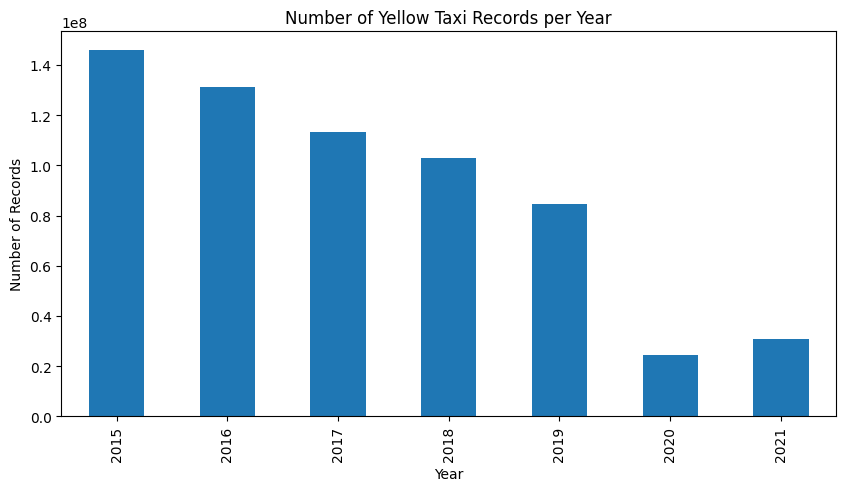

In [10]:
# Visualisierung der Records
year_counts_pd = year_counts_df.orderBy("year").toPandas()

ax = year_counts_pd.plot(
    x="year",
    y="number_of_records",
    kind="bar",
    figsize=(10, 5),
    title="Number of Yellow Taxi Records per Year",
    legend=False
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Records")

In [ ]:
Die Tiefe Anzahl Fahrten im Jahr 2020 und 2021 könnten auf Corona zurückzuführen sein. Obwohl ein Downtrend ersichtlich ist, macht dieser Sprung so keinen Sinn

In [ ]:
Min und Max Datum Pro Jahr prüfen

In [11]:
date_ranges = []

for year in YEARS:
    path = f"{BASE_PATH}/{year}/*.parquet"
    df_year = spark.read.parquet(path)
    
    result = df_year.agg(
        F.min("tpep_pickup_datetime").alias("min_pickup_datetime"),
        F.max("tpep_pickup_datetime").alias("max_pickup_datetime"),
        F.min("tpep_dropoff_datetime").alias("min_dropoff_datetime"),
        F.max("tpep_dropoff_datetime").alias("max_dropoff_datetime")
    ).collect()[0]
    
    date_ranges.append((
        year,
        result["min_pickup_datetime"],
        result["max_pickup_datetime"],
        result["min_dropoff_datetime"],
        result["max_dropoff_datetime"]
    ))

date_ranges_df = spark.createDataFrame(
    date_ranges,
    [
        "year",
        "min_pickup_datetime",
        "max_pickup_datetime",
        "min_dropoff_datetime",
        "max_dropoff_datetime"
    ]
)

date_ranges_df.show(truncate=False)

+----+-------------------+-------------------+--------------------+--------------------+
|year|min_pickup_datetime|max_pickup_datetime|min_dropoff_datetime|max_dropoff_datetime|
+----+-------------------+-------------------+--------------------+--------------------+
|2015|2015-01-01 00:00:00|2015-12-31 23:59:59|1900-01-01 00:00:00 |2253-08-23 07:56:38 |
|2016|2016-01-01 00:00:00|2016-12-31 23:59:58|1996-06-20 16:23:24 |2017-01-01 23:38:44 |
|2017|2001-01-01 00:04:13|2053-03-21 16:47:33|1997-07-22 15:30:46 |2053-03-21 16:52:21 |
|2018|2001-01-01 00:01:48|2084-11-04 12:32:24|1926-08-10 21:42:11 |2084-11-04 12:47:41 |
|2019|2001-01-01 00:02:08|2090-12-31 06:41:26|2001-01-01 01:00:02 |2090-12-31 07:18:49 |
|2020|2002-12-31 23:06:55|2021-06-10 10:10:48|2002-12-31 23:08:03 |2021-06-10 10:41:42 |
|2021|2002-12-31 23:07:20|2098-09-11 02:23:31|2003-01-01 00:38:46 |2098-09-11 02:52:04 |
+----+-------------------+-------------------+--------------------+--------------------+



In [12]:
invalid_datetime_counts = []

for year in YEARS:
    path = f"{BASE_PATH}/{year}/*.parquet"
    df_year = spark.read.parquet(path)
    
    invalid_pickup = df_year.filter(
        (F.year("tpep_pickup_datetime") != year)
    ).count()
    
    invalid_dropoff = df_year.filter(
        (F.year("tpep_dropoff_datetime") != year)
    ).count()
    
    total_records = df_year.count()
    
    invalid_datetime_counts.append((
        year,
        total_records,
        invalid_pickup,
        invalid_dropoff,
        round(invalid_pickup / total_records * 100, 4),
        round(invalid_dropoff / total_records * 100, 4)
    ))

invalid_datetime_df = spark.createDataFrame(
    invalid_datetime_counts,
    [
        "year",
        "total_records",
        "invalid_pickup_year",
        "invalid_dropoff_year",
        "invalid_pickup_percent",
        "invalid_dropoff_percent"
    ]
)

invalid_datetime_df.show(truncate=False)

+----+-------------+-------------------+--------------------+----------------------+-----------------------+
|year|total_records|invalid_pickup_year|invalid_dropoff_year|invalid_pickup_percent|invalid_dropoff_percent|
+----+-------------+-------------------+--------------------+----------------------+-----------------------+
|2015|146039231    |0                  |2406                |0.0                   |0.0016                 |
|2016|131131805    |0                  |1949                |0.0                   |0.0015                 |
|2017|113500327    |168                |1896                |1.0E-4                |0.0017                 |
|2018|102871387    |1282               |2784                |0.0012                |0.0027                 |
|2019|84598444     |1442               |2507                |0.0017                |0.003                  |
|2020|24649092     |280                |400                 |0.0011                |0.0016                 |
|2021|30904308     

In [ ]:
Nur die Pickup Time aus 2015 und 2016 ergeben sinn. Alle Weiteren Daten müssen bei Data Quality noch bereinigt werden.

In [ ]:
Erste Daten Exploration für Jahr 2021

In [36]:
#Einzelnes Jahr Laden und erste Zeilen anzeigen
df_2021 = spark.read.parquet(f"{BASE_PATH}/2021/*.parquet")
df_2021.show(5, truncate=False)

26/05/18 13:14:20 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/05/18 13:14:35 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
[Stage 1:>                                                          (0 + 1) / 1]

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2021-09-01 06:04:34 |2021-09-01 06:15:28  |2.0            |4.9          |1.0       |N                 |87          |229         |1           |16.0       |0.5  |0.5    |2.0      

In [19]:
# Schema nochmals besser anzeigen
schema_df = spark.createDataFrame(
    [(field.name, field.dataType.simpleString(), field.nullable) for field in df_2021.schema.fields],
    ["column_name", "data_type", "nullable"]
)

schema_df.show(truncate=False)

+---------------------+-------------+--------+
|column_name          |data_type    |nullable|
+---------------------+-------------+--------+
|VendorID             |bigint       |true    |
|tpep_pickup_datetime |timestamp_ntz|true    |
|tpep_dropoff_datetime|timestamp_ntz|true    |
|passenger_count      |double       |true    |
|trip_distance        |double       |true    |
|RatecodeID           |double       |true    |
|store_and_fwd_flag   |string       |true    |
|PULocationID         |bigint       |true    |
|DOLocationID         |bigint       |true    |
|payment_type         |bigint       |true    |
|fare_amount          |double       |true    |
|extra                |double       |true    |
|mta_tax              |double       |true    |
|tip_amount           |double       |true    |
|tolls_amount         |double       |true    |
|improvement_surcharge|double       |true    |
|total_amount         |double       |true    |
|congestion_surcharge |double       |true    |
|airport_fee 

In [ ]:
Nur Relevante Zeilen nehmen

In [37]:
selected_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "PULocationID",
    "DOLocationID"
]

df_2021_selected = df_2021.select(selected_columns)

df_2021_selected.show(5, truncate=False)

[Stage 2:>                                                          (0 + 1) / 1]

+--------------------+---------------------+---------------+-------------+------------+-----------+----------+------------+------------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|payment_type|fare_amount|tip_amount|total_amount|PULocationID|DOLocationID|
+--------------------+---------------------+---------------+-------------+------------+-----------+----------+------------+------------+------------+
|2021-09-01 06:04:34 |2021-09-01 06:15:28  |2.0            |4.9          |1           |16.0       |2.0       |21.8        |87          |229         |
|2021-09-01 06:26:31 |2021-09-01 06:32:39  |1.0            |1.13         |1           |6.0        |1.96      |11.76       |162         |229         |
|2021-09-01 06:36:15 |2021-09-01 06:40:30  |2.0            |1.37         |1           |6.0        |1.96      |11.76       |141         |262         |
|2021-09-01 00:00:15 |2021-09-01 00:18:34  |2.0            |6.5          |2           |21.0       |0

In [21]:
#Wichtige Spalten anschauen
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

df_2021_selected.select(numeric_columns).describe().show()

26/05/15 19:24:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 206:==================================================>    (12 + 1) / 13]

+-------+------------------+-----------------+------------------+------------------+------------------+
|summary|   passenger_count|    trip_distance|       fare_amount|        tip_amount|      total_amount|
+-------+------------------+-----------------+------------------+------------------+------------------+
|  count|          29425613|         30904308|          30904308|          30904308|          30904308|
|   mean|1.4274682399989425|6.922688674342552|  13.5193386922125| 2.341164260659189|19.696304829515167|
| stddev|1.0333753094086415|698.3799511182599|178.98867861481367|2.8290292271377875|179.19426093049074|
|    min|               0.0|              0.0|            -758.0|           -333.32|            -951.0|
|    max|             112.0|        351613.36|         818283.44|           1140.44|         818286.74|
+-------+------------------+-----------------+------------------+------------------+------------------+



In [ ]:
Auffällig viele Spalten enthalten werte die gar keinen Sinn machen.
Die Späteren Tests ergeben ein besseres Bild welche Spalten wie stark betroffen sind
    
Für Data Quality vermerken um entsprechende Bereinigung durchzuführen

In [22]:
#0 Werte Prüfen

null_checks = []

for column in selected_columns:
    null_count = df_2021_selected.filter(F.col(column).isNull()).count()
    null_checks.append((column, null_count))

null_checks_df = spark.createDataFrame(
    null_checks,
    ["column_name", "null_count"]
)

null_checks_df.show()

+--------------------+----------+
|         column_name|null_count|
+--------------------+----------+
|tpep_pickup_datetime|         0|
|tpep_dropoff_date...|         0|
|     passenger_count|   1478695|
|       trip_distance|         0|
|        payment_type|         0|
|         fare_amount|         0|
|          tip_amount|         0|
|        total_amount|         0|
|        PULocationID|         0|
|        DOLocationID|         0|
+--------------------+----------+



In [41]:
#Plausibilitätsprüfung
numeric_quality_checks = df_2021_selected.agg(
    F.count("*").alias("total_records"),

    F.sum(F.when(F.col("passenger_count").isNull(), 1).otherwise(0)).alias("passenger_count_null"),
    F.sum(F.when(F.col("passenger_count") <= 0, 1).otherwise(0)).alias("passenger_count_leq_0"),
    F.sum(F.when(F.col("passenger_count") > 6, 1).otherwise(0)).alias("passenger_count_gt_6"),

    F.sum(F.when(F.col("trip_distance").isNull(), 1).otherwise(0)).alias("trip_distance_null"),
    F.sum(F.when(F.col("trip_distance") <= 0, 1).otherwise(0)).alias("trip_distance_leq_0"),
    F.sum(F.when(F.col("trip_distance") > 100, 1).otherwise(0)).alias("trip_distance_gt_100"),

    F.sum(F.when(F.col("fare_amount") < 0, 1).otherwise(0)).alias("fare_amount_negative"),
    F.sum(F.when(F.col("tip_amount") < 0, 1).otherwise(0)).alias("tip_amount_negative"),
    F.sum(F.when(F.col("total_amount") <= 0, 1).otherwise(0)).alias("total_amount_leq_0"),
    F.sum(F.when(F.col("total_amount") > 1000, 1).otherwise(0)).alias("total_amount_gt_1000")
)

numeric_quality_checks.show(truncate=False)

[Stage 4:================================================>        (11 + 2) / 13]

+-------------+--------------------+---------------------+--------------------+------------------+-------------------+--------------------+--------------------+-------------------+------------------+--------------------+
|total_records|passenger_count_null|passenger_count_leq_0|passenger_count_gt_6|trip_distance_null|trip_distance_leq_0|trip_distance_gt_100|fare_amount_negative|tip_amount_negative|total_amount_leq_0|total_amount_gt_1000|
+-------------+--------------------+---------------------+--------------------+------------------+-------------------+--------------------+--------------------+-------------------+------------------+--------------------+
|30904308     |1478695             |703955               |164                 |0                 |407812             |2756                |139326              |2625               |146951            |22                  |
+-------------+--------------------+---------------------+--------------------+------------------+------------------

In [25]:
# mit % werten

total_2021 = df_2021_selected.count()

numeric_quality_percentages = numeric_quality_checks.select(
    F.col("total_records"),
    F.round(F.col("passenger_count_null") / total_2021 * 100, 4).alias("passenger_count_null_pct"),
    F.round(F.col("passenger_count_leq_0") / total_2021 * 100, 4).alias("passenger_count_leq_0_pct"),
    F.round(F.col("passenger_count_gt_6") / total_2021 * 100, 4).alias("passenger_count_gt_6_pct"),
    F.round(F.col("trip_distance_leq_0") / total_2021 * 100, 4).alias("trip_distance_leq_0_pct"),
    F.round(F.col("trip_distance_gt_100") / total_2021 * 100, 4).alias("trip_distance_gt_100_pct"),
    F.round(F.col("fare_amount_negative") / total_2021 * 100, 4).alias("fare_amount_negative_pct"),
    F.round(F.col("tip_amount_negative") / total_2021 * 100, 4).alias("tip_amount_negative_pct"),
    F.round(F.col("total_amount_leq_0") / total_2021 * 100, 4).alias("total_amount_leq_0_pct"),
    F.round(F.col("total_amount_gt_1000") / total_2021 * 100, 4).alias("total_amount_gt_1000_pct")
)

numeric_quality_percentages.show(truncate=False)

[Stage 251:==========================================>            (10 + 3) / 13]

+-------------+------------------------+-------------------------+------------------------+-----------------------+------------------------+------------------------+-----------------------+----------------------+------------------------+
|total_records|passenger_count_null_pct|passenger_count_leq_0_pct|passenger_count_gt_6_pct|trip_distance_leq_0_pct|trip_distance_gt_100_pct|fare_amount_negative_pct|tip_amount_negative_pct|total_amount_leq_0_pct|total_amount_gt_1000_pct|
+-------------+------------------------+-------------------------+------------------------+-----------------------+------------------------+------------------------+-----------------------+----------------------+------------------------+
|30904308     |4.7848                  |2.2779                   |5.0E-4                  |1.3196                 |0.0089                  |0.4508                  |0.0085                 |0.4755                |1.0E-4                  |
+-------------+------------------------+--------

In [ ]:
Erste Testberechunge durchführen

In [42]:
# Fartdauer berechnen

df_2021_duration = df_2021_selected.withColumn(
    "trip_duration_minutes",
    (
        F.unix_timestamp("tpep_dropoff_datetime")
        - F.unix_timestamp("tpep_pickup_datetime")
    ) / 60
)

df_2021_duration.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "total_amount"
).show(10, truncate=False)

+--------------------+---------------------+---------------------+-------------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_duration_minutes|trip_distance|total_amount|
+--------------------+---------------------+---------------------+-------------+------------+
|2021-09-01 06:04:34 |2021-09-01 06:15:28  |10.9                 |4.9          |21.8        |
|2021-09-01 06:26:31 |2021-09-01 06:32:39  |6.133333333333334    |1.13         |11.76       |
|2021-09-01 06:36:15 |2021-09-01 06:40:30  |4.25                 |1.37         |11.76       |
|2021-09-01 00:00:15 |2021-09-01 00:18:34  |18.316666666666666   |6.5          |31.35       |
|2021-09-01 00:44:54 |2021-09-01 00:56:33  |11.65                |2.32         |11.8        |
|2021-09-01 00:15:08 |2021-09-01 00:21:39  |6.516666666666667    |1.6          |14.1        |
|2021-09-01 00:35:36 |2021-09-01 00:57:56  |22.333333333333332   |7.6          |35.15       |
|2021-09-01 00:34:09 |2021-09-01 00:42:25  |8.26666666666666

In [43]:
# Geschwindigkeit 

df_2021_speed = df_2021_duration \
    .withColumn("trip_distance_km", F.col("trip_distance") * 1.60934) \
    .withColumn(
        "avg_speed_kmh",
        F.col("trip_distance_km") / (F.col("trip_duration_minutes") / 60)
    )

df_2021_speed.select(
    "trip_distance",
    "trip_distance_km",
    "trip_duration_minutes",
    "avg_speed_kmh"
).show(10)

+-------------+------------------+---------------------+------------------+
|trip_distance|  trip_distance_km|trip_duration_minutes|     avg_speed_kmh|
+-------------+------------------+---------------------+------------------+
|          4.9|          7.885766|                 10.9| 43.40788623853211|
|         1.13|         1.8185542|    6.133333333333334| 17.79020413043478|
|         1.37|2.2047958000000003|                 4.25|31.126528941176474|
|          6.5|          10.46071|   18.316666666666666| 34.26620200181984|
|         2.32|         3.7336688|                11.65|19.229195536480685|
|          1.6|2.5749440000000003|    6.516666666666667|23.707924296675195|
|          7.6|         12.230984|   22.333333333333332|          32.85936|
|         1.24|         1.9955816|    8.266666666666667|14.484059999999998|
|         11.2|18.024607999999997|   27.466666666666665|39.374143689320384|
|         5.53|         8.8996502|   22.766666666666666|23.454422196193267|
+-----------

In [44]:
# Statistik daraus

df_2021_speed.select(
    "trip_duration_minutes",
    "trip_distance_km",
    "avg_speed_kmh"
).describe().show()

[Stage 9:========================================>                 (9 + 4) / 13]

+-------+---------------------+------------------+--------------------+
|summary|trip_duration_minutes|  trip_distance_km|       avg_speed_kmh|
+-------+---------------------+------------------+--------------------+
|  count|             30904308|          30904308|            30882598|
|   mean|    16.58373447104363|11.140959791168065|  42.681231257848545|
| stddev|    67.36467409964958| 1123.930790532663|   7704.823041967291|
|    min|  -135084.63333333333|               0.0|       -147969.15696|
|    max|   29336.516666666666| 565865.4447823999|1.5202179694799999E7|
+-------+---------------------+------------------+--------------------+



In [ ]:
Übersicht von Tagen und Stunden der jeweiligen Fahrten verschafen

In [45]:
df_2021_hourly = df_2021_speed.withColumn(
    "pickup_hour",
    F.hour("tpep_pickup_datetime")
)

hourly_counts_2021 = df_2021_hourly.groupBy("pickup_hour") \
    .agg(F.count("*").alias("number_of_records")) \
    .orderBy("pickup_hour")

hourly_counts_2021.show(24)

[Stage 12:===============================================>        (11 + 2) / 13]

+-----------+-----------------+
|pickup_hour|number_of_records|
+-----------+-----------------+
|          0|           688852|
|          1|           439872|
|          2|           287198|
|          3|           183388|
|          4|           132989|
|          5|           180635|
|          6|           484048|
|          7|           890135|
|          8|          1238847|
|          9|          1403933|
|         10|          1571355|
|         11|          1722542|
|         12|          1887345|
|         13|          1938989|
|         14|          2091387|
|         15|          2130110|
|         16|          2054505|
|         17|          2171586|
|         18|          2208574|
|         19|          1930833|
|         20|          1560310|
|         21|          1414016|
|         22|          1281126|
|         23|          1011733|
+-----------+-----------------+



Text(0, 0.5, 'Number of Records')

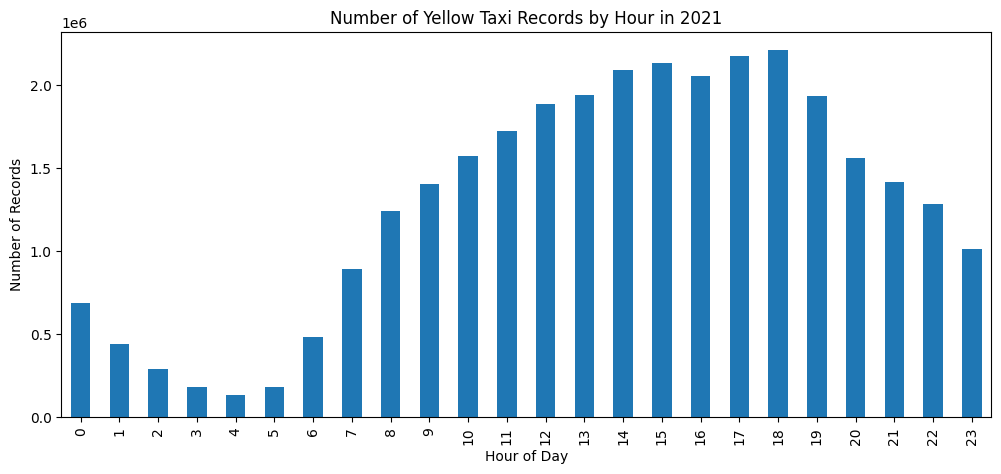

In [46]:
hourly_counts_2021_pd = hourly_counts_2021.toPandas()

ax = hourly_counts_2021_pd.plot(
    x="pickup_hour",
    y="number_of_records",
    kind="bar",
    figsize=(12, 5),
    title="Number of Yellow Taxi Records by Hour in 2021",
    legend=False
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Records")

In [47]:
spark.stop()